In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sudhasreeyerramsetty","key":"d86bfcee1b5399f8e7c15fe2bde626de"}'}

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d awsaf49/brats2020-training-data

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats2020-training-data
License(s): CC0-1.0
100% 6.76G/6.76G [06:29<00:00, 18.6MB/s]



In [5]:
!unzip -q brats2020-training-data.zip

In [6]:
!ls

 BraTS2020_training_data      'BraTS20 Training Metadata.csv'
 brats2020-training-data.zip   sample_data


In [7]:
!ls BraTS2020_training_data/content/data | head

meta_data.csv
name_mapping.csv
survival_info.csv
volume_100_slice_0.h5
volume_100_slice_100.h5
volume_100_slice_101.h5
volume_100_slice_102.h5
volume_100_slice_103.h5
volume_100_slice_104.h5
volume_100_slice_105.h5


In [8]:
!pip install timm h5py
import pandas as pd

df = pd.read_csv("BraTS20 Training Metadata.csv")
df.head()

,slice_path,target,volume,slice,label0_pxl_cnt,label1_pxl_cnt,label2_pxl_cnt,background_ratio
0,../input/brats2020-training-data/BraTS2020_tra...,0,41,0,0,0,0,1.0
1,../input/brats2020-training-data/BraTS2020_tra...,0,41,1,0,0,0,1.0
2,../input/brats2020-training-data/BraTS2020_tra...,0,41,2,0,0,0,1.0
3,../input/brats2020-training-data/BraTS2020_tra...,0,41,3,0,0,0,1.0
4,../input/brats2020-training-data/BraTS2020_tra...,0,41,4,0,0,0,1.0


In [9]:
df['slice_path'] = df['slice_path'].apply(
    lambda x: x.replace(
        '../input/brats2020-training-data/',
        ''
    )
)

In [10]:
# loading a sample h5 file
import h5py

sample_path = df.iloc[0]['slice_path']

with h5py.File(sample_path, 'r') as f:
    image = f['image'][:]
    mask = f['mask'][:]

print(image.shape, mask.shape)

(240, 240, 4) (240, 240, 3)


(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

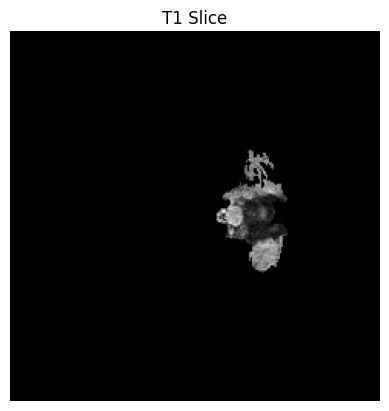

In [11]:
# visualize one slice
import matplotlib.pyplot as plt

plt.imshow(image[:, :, 0], cmap='gray')
plt.title("T1 Slice")
plt.axis('off')

In [12]:
# group slices by patient
df = df.sort_values(by=['volume', 'slice'])
patient_groups = df.groupby('volume')

In [13]:
patient_id = 1
patient_df = patient_groups.get_group(patient_id)

print(len(patient_df))

155


In [14]:
# build patient level label
import numpy as np

def get_patient_label(patient_df):
    NCR = int(patient_df['label1_pxl_cnt'].sum() > 0)
    ED  = int(patient_df['label2_pxl_cnt'].sum() > 0)
    ET  = int(patient_df['label0_pxl_cnt'].sum() > 0)
    return np.array([NCR, ED, ET])

In [15]:
import h5py
import cv2
import numpy as np

def load_and_preprocess_slice(path):
    with h5py.File(path, 'r') as f:
        img = f['image'][:]

    img = np.stack([
      cv2.resize(img[:, :, c], (224, 224))
      for c in range(4)
    ], axis=-1)

    img = img.astype(np.float32)
    for c in range(4):
        channel = img[:, :, c]
        channel = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)
        img[:, :, c] = channel

    return img

In [16]:
# load all slices for one patient
def load_patient(patient_df):
    patient_df = patient_df.sort_values('slice').reset_index(drop=True)
    slices = []

    for path in patient_df['slice_path']:
        img = load_and_preprocess_slice(path)
        slices.append(img)

    slices = np.stack(slices)
    slices = np.transpose(slices, (0, 3, 1, 2))
    label = get_patient_label(patient_df)

    return slices, label

In [17]:
# test on one patient
patient_id = 1
patient_df = patient_groups.get_group(patient_id)

X, y = load_patient(patient_df)

print("Input shape:", X.shape)
print("Label:", y.shape)

Input shape: (155, 4, 224, 224)
Label: (3,)


In [18]:
# train-val split
from sklearn.model_selection import train_test_split

patient_ids = list(patient_groups.groups.keys())

train_ids, temp_ids = train_test_split(patient_ids, test_size=0.3, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

print(len(train_ids), len(val_ids), len(test_ids))

258 55 56


In [19]:
# pytorch dataset
import torch
from torch.utils.data import Dataset

class BraTSDataset(Dataset):
    def __init__(self, df, patient_ids):
        self.df = df
        self.patient_ids = patient_ids
        self.groups = df.groupby('volume')

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, idx):
        patient_id = self.patient_ids[idx]
        patient_df = self.groups.get_group(patient_id)

        X, y = load_patient(patient_df)

        return torch.tensor(X), torch.tensor(y, dtype=torch.float32)

In [20]:
# creating dataloaders
from torch.utils.data import DataLoader

train_dataset = BraTSDataset(df, train_ids)
val_dataset   = BraTSDataset(df, val_ids)
test_dataset = BraTSDataset(df, test_ids)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [21]:
# modifying vit for 4 channels
import timm
import torch
import torch.nn as nn

def create_vit_4ch():
    model = timm.create_model('vit_base_patch16_224', pretrained=True)

    old_conv = model.patch_embed.proj

    new_conv = nn.Conv2d(
        in_channels=4,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None)
    )

    new_conv.weight.data[:, :3, :, :] = old_conv.weight.data
    new_conv.weight.data[:, 3, :, :] = old_conv.weight.data.mean(dim=1)

    model.patch_embed.proj = new_conv

    return model

In [22]:
# vit + mean pooling
class ViTMeanPooling(nn.Module):
    def __init__(self):
        super().__init__()

        self.vit = create_vit_4ch()
        self.vit.reset_classifier(0)

        for param in self.vit.parameters():
          param.requires_grad = True

        self.fc = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        B, S, C, H, W = x.shape

        chunk_size = 4

        all_features = []

        for i in range(0, S, chunk_size):
            x_chunk = x[:, i:i+chunk_size]

            b, s, c, h, w = x_chunk.shape
            x_chunk = x_chunk.reshape(b * s, c, h, w)

            with torch.no_grad():
              features = self.vit(x_chunk)

            features = features.view(b, s, -1)

            all_features.append(features)

        features = torch.cat(all_features, dim=1)

        # mean pooling
        pooled = features.mean(dim=1)

        out = self.fc(pooled)

        return out

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ViTMeanPooling().to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [24]:
# handling class imbalance
labels = []

for pid in train_ids:
    patient_df = patient_groups.get_group(pid)
    labels.append(get_patient_label(patient_df))

labels = np.array(labels)

pos_counts = labels.sum(axis=0)
neg_counts = len(labels) - pos_counts

pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-8), dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [25]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

In [26]:
# training loop
!pip install tqdm

from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

    for X, y in tqdm(loader, desc="Training", leave=False):
        X = X.to(device).float()
        y = y.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type):
            outputs = model(X)
            loss = criterion(outputs, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

In [27]:
# validation loop
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X, y in tqdm(loader, desc="Validation", leave=False):
            X = X.to(device).float()
            y = y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            total_loss += loss.item()

    return total_loss / len(loader)

In [28]:
import os
os.makedirs("checkpoints", exist_ok=True)

def save_checkpoint(model, optimizer, epoch, val_loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss
    }, path)

In [29]:
num_epochs = 30

best_val_loss = float('inf')
patience = 3
counter = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        save_checkpoint(model, optimizer, epoch, val_loss, "checkpoints/best_model.pth")
        print("Model saved.")

    else:
        counter += 1
        print(f"No improvement. Patience: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1
Train Loss: 0.0378
Val Loss: 0.0351
Model saved.


Epoch 2
Train Loss: 0.0373
Val Loss: 0.0349
Model saved.


Epoch 3
Train Loss: 0.0379
Val Loss: 0.0348
Model saved.


Epoch 4
Train Loss: 0.0368
Val Loss: 0.0346
Model saved.


Epoch 5
Train Loss: 0.0367
Val Loss: 0.0344
Model saved.


...

Epoch 26
Train Loss: 0.0340
Val Loss: 0.0332
Model saved.


Epoch 27
Train Loss: 0.0361
Val Loss: 0.0332
Model saved.


Epoch 28
Train Loss: 0.0342
Val Loss: 0.0332
No improvement. Patience: 1/3


Epoch 29
Train Loss: 0.0345
Val Loss: 0.0332
Model saved.


Epoch 30
Train Loss: 0.0345
Val Loss: 0.0332
Model saved.


In [30]:
# saving checkpoints
checkpoint = torch.load("checkpoints/best_model.pth")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

ViTMeanPooling(
  (vit): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(4, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (a

In [33]:
# predictions
import torch

def get_predictions(model, loader, device):
    model.eval()

    all_targets = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device).float()
            y = y.to(device)

            outputs = model(X)

            probs = torch.sigmoid(outputs)

            threshold_array = torch.tensor([0.5, 0.5, 0.4], device=probs.device)
            preds = (probs > threshold_array).float()

            all_targets.append(y.cpu())
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())

    all_targets = torch.cat(all_targets)
    all_probs = torch.cat(all_probs)
    all_preds = torch.cat(all_preds)

    return all_targets.numpy(), all_probs.numpy(), all_preds.numpy()

In [34]:
# classification report
from sklearn.metrics import accuracy_score, f1_score, hamming_loss, classification_report

targets, probs, preds = get_predictions(model, test_loader, device)

print("Classification Report:")
print(classification_report(
    targets,
    preds,
    target_names=["NCR", "ED", "ET"]
))

accuracy = 1 - hamming_loss(targets, preds)
print(f"\nAccuracy (label-wise): {accuracy:.4f}")

# these are better metrics for multi label classification compared to accuracy
print("Macro F1:", f1_score(targets, preds, average='macro'))
print("Micro F1:", f1_score(targets, preds, average='micro'))

Classification Report:
              precision    recall  f1-score   support

         NCR       1.00      0.15      0.25        55
          ED       0.98      0.77      0.86        53
          ET       1.00      1.00      1.00        56

   micro avg       0.99      0.64      0.78       164
   macro avg       0.99      0.64      0.71       164
weighted avg       0.99      0.64      0.71       164
 samples avg       0.99      0.64      0.76       164


Accuracy (label-wise): 0.6429
Macro F1: 0.7057087162350321
Micro F1: 0.7777777777777778


In [37]:
from sklearn.metrics import log_loss
import numpy as np

log_losses = {}

for i, label in enumerate(["NCR", "ED", "ET"]):
    try:
        loss = log_loss(targets[:, i], probs[:, i])
        log_losses[label] = float(loss)
        print(f"{label} Log Loss:", loss)
    except ValueError:
        log_losses[label] = None
        print(f"{label} Log Loss: None (only one class present)")

# ---- mean log loss (ignore None) ----
valid_losses = [v for v in log_losses.values() if v is not None]

mean_log_loss = float(np.mean(valid_losses)) if len(valid_losses) > 0 else None

print("Mean Log Loss:", mean_log_loss)

NCR Log Loss: 0.7123124309795806
ED Log Loss: 0.600647031264873
ET Log Loss: None (only one class present)
Mean Log Loss: 0.6564797311222268


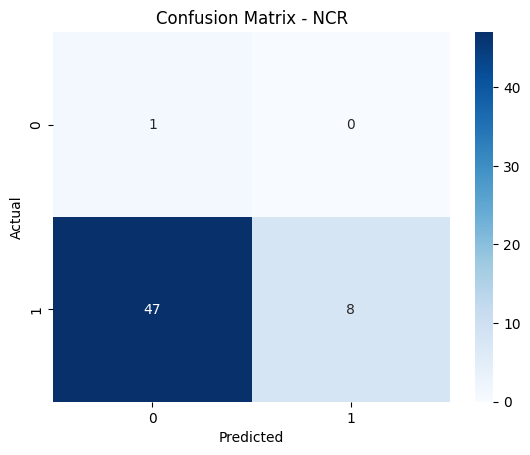

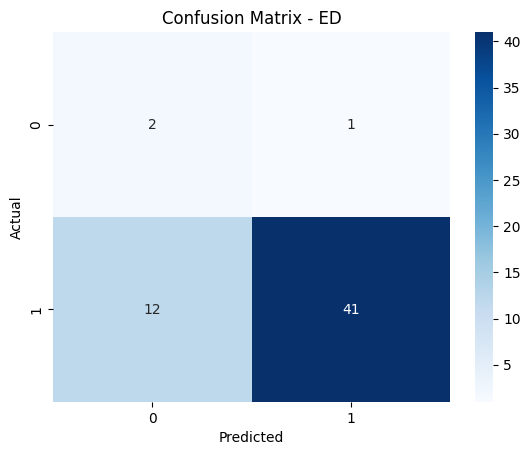

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


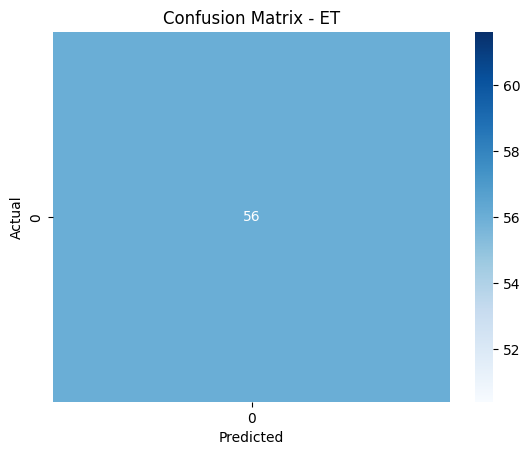

In [38]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["NCR", "ED", "ET"]

for i in range(3):
    cm = confusion_matrix(targets[:, i], preds[:, i])

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {labels[i]}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Skipping ROC for ET (only one class present)


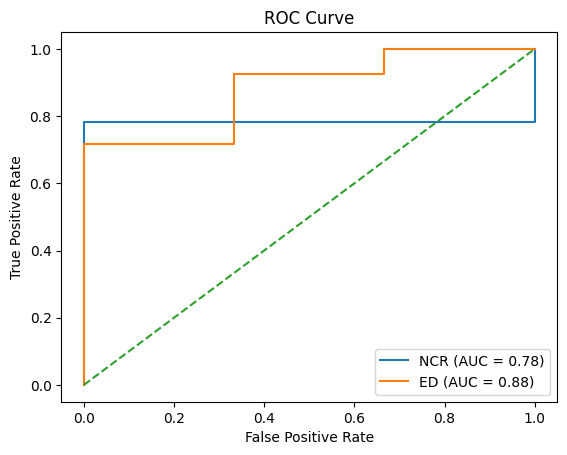

In [39]:
# NOTE: ROC and PR curves were computed only when both positive and negative samples were present for a class since these metrics are undefined otherwise

# roc-auc
from sklearn.metrics import roc_curve, auc

plt.figure()

for i, label in enumerate(["NCR", "ED", "ET"]):
    if len(np.unique(targets[:, i])) < 2:
        print(f"Skipping ROC for {label} (only one class present)")
        continue

    fpr, tpr, _ = roc_curve(targets[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [40]:
# macro auroc
from sklearn.metrics import roc_auc_score

aucs = []

for i in range(3):
    if len(np.unique(targets[:, i])) < 2:
        continue
    auc_score = roc_auc_score(targets[:, i], probs[:, i])
    aucs.append(auc_score)

print("Macro AUROC:", np.mean(aucs))

Macro AUROC: 0.831160663236135


Skipping PR curve for ET (only one class present)


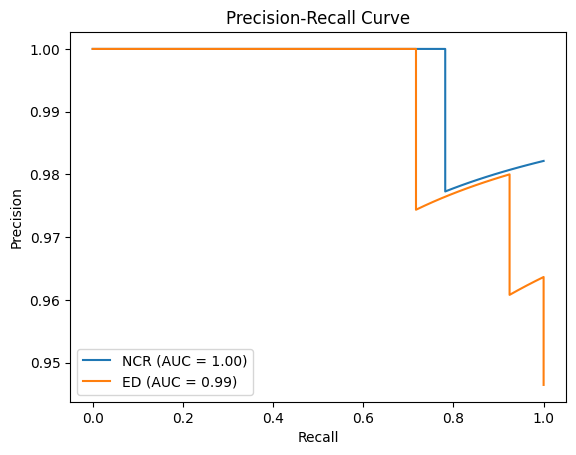

In [41]:
# pr-auc
from sklearn.metrics import precision_recall_curve, auc

plt.figure()

for i, label in enumerate(["NCR", "ED", "ET"]):
    if len(np.unique(targets[:, i])) < 2:
        print(f"Skipping PR curve for {label} (only one class present)")
        continue

    precision, recall, _ = precision_recall_curve(targets[:, i], probs[:, i])
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f"{label} (AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [42]:
import json
from sklearn.metrics import roc_auc_score, log_loss, precision_score, recall_score, f1_score

thresholds = {
    "NCR": 0.5,
    "ED": 0.5,
    "ET": 0.4
}

accuracy = accuracy_score(targets, preds)

auroc = {}
for i, label in enumerate(["NCR", "ED", "ET"]):
    try:
        auroc[label] = roc_auc_score(targets[:, i], probs[:, i])
    except:
        auroc[label] = None

valid_aurocs = [v for v in auroc.values() if v is not None]
macro_auroc = np.mean(valid_aurocs) if valid_aurocs else None

log_losses = {}
for i, label in enumerate(["NCR", "ED", "ET"]):
    try:
        log_losses[label] = log_loss(targets[:, i], probs[:, i])
    except:
        log_losses[label] = None

valid_ll = [v for v in log_losses.values() if v is not None]
mean_log_loss = np.mean(valid_ll) if valid_ll else None

per_class = {}
for i, label in enumerate(["NCR", "ED", "ET"]):
    per_class[label] = {
        "precision": precision_score(targets[:, i], preds[:, i], zero_division=0),
        "recall": recall_score(targets[:, i], preds[:, i], zero_division=0),
        "f1": f1_score(targets[:, i], preds[:, i], zero_division=0)
    }

results = {
    "model": "ViT + Mean Pooling",
    "thresholds": thresholds,
    "accuracy": float(accuracy),
    "auroc": auroc,
    "macro_auroc": float(macro_auroc) if macro_auroc is not None else None,
    "log_loss": log_losses,
    "mean_log_loss": float(mean_log_loss) if mean_log_loss is not None else None,
    "all_probs": probs.tolist(),
    "all_preds": preds.tolist(),
    "all_labels": targets.tolist(),
    "per_class": per_class
}

with open("vit_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved vit_results.json")

Saved vit_results.json


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
